# 02 - Baselines

**The one sentence for today: yesterday I measured the problem, today I measure the floor.**

Without a number saying "how good is this with no language model at all", tomorrow's
fine-tuned score means nothing - not in the report, not in the presentation, and not
in the oral exam.

Three things come out of this notebook, all on CPU, zero GPU units:

1. **The floor.** What a model that does not read the text scores. Measured, not
   computed as 1/27 - after the family collapse the classes are no longer balanced.
2. **The reference model.** TF-IDF + logistic regression: weighted word counts and a
   linear classifier, seconds to train.
3. **The leakage, converted from a property of the data into a difference in score.**
   Day 1 proved that naive-split test rows sit next to training rows. That is a claim
   about the *dataset*. Today it becomes a claim about a *number*.

Everything is measured on **`val`**. `test` is opened exactly once, at the end of the
project, together with the final model. A baseline is precisely where a test set gets
burned: you measure, dislike the number, change the vectoriser, and the test set has
quietly become a tuning set.

## 0 - Bootstrap and verify the frozen split

In [1]:
import json, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo root, whether this runs locally or from a Colab clone.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "data.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src import data as D
from src import baselines as B
from src import evaluate as E

METRICS_DIR = REPO_ROOT / "results" / "metrics"
ERRORS_DIR  = REPO_ROOT / "results" / "errors"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
for d in (METRICS_DIR, ERRORS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT.name)
print("python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)

repo: support-triage
python 3.13.14 | pandas 3.0.3 | numpy 2.5.1


### The manifest check comes first, before any number is produced

A check that runs *after* the results exist is decoration. If the split on this machine
is not the split described in `split_manifest.json`, then every number below describes a
different dataset than the report does - and nothing about that failure is visible
without hashing the files.

`load_all_splits()` reads all six CSVs, including `test`. Loading `test` is not the same
as scoring on it: the manifest has to hash all six files or it is not checking the split.

In [2]:
manifest = json.loads((REPO_ROOT / "data" / "processed" / "split_manifest.json").read_text())
splits = D.load_all_splits(REPO_ROOT / "data" / "processed")

D.verify_against_manifest(manifest, splits)   # raises on any mismatch
print("manifest verified - all six split files match the frozen fingerprints\n")

for name, parts in splits.items():
    print(f"{name:6s}", " ".join(f"{p}={len(f):,}" for p, f in parts.items()))

print(f"\nsplit seed        {manifest['seed']}")
print(f"near-dup threshold {manifest['near_dup_threshold']}")
print(f"MAX_LENGTH         {D.MAX_LENGTH}  (measured on day 1: p99 = 19 tokens)")

manifest verified - all six split files match the frozen fingerprints

clean  train=9,893 val=2,120 test=2,120
naive  train=17,187 val=3,683 test=3,684

split seed        42
near-dup threshold 0.9
MAX_LENGTH         32  (measured on day 1: p99 = 19 tokens)


### The label lists, loaded from the contract

`artifacts/labels.json` is the frozen class order. Every scoring call below receives it
explicitly. This is the single most important detail in this notebook: without an
explicit label list, `f1_score(average="macro")` averages over whichever classes happen
to appear in `y_true` or `y_pred`. An intent the model never predicts silently drops the
average from 27 classes to 26 - **the score goes up and nothing complains.**

In [3]:
INTENTS = json.loads((REPO_ROOT / "artifacts" / "labels.json").read_text())
INTENT2CAT = json.loads((REPO_ROOT / "artifacts" / "intent2cat.json").read_text())
CATEGORIES = sorted(set(INTENT2CAT.values()))

assert len(INTENTS) == 27, len(INTENTS)
assert len(CATEGORIES) == 11, len(CATEGORIES)
print(f"{len(INTENTS)} intents, {len(CATEGORIES)} categories")
print(CATEGORIES)

RECORDS = []   # every run appends one record; written to disk at the end

27 intents, 11 categories
['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']


## 1 - Re-prove the split guarantee, and measure what the naive split really contains

Before comparing anything, establish inside *this* notebook what the two splits actually
are. Two numbers matter, and the second one is the basis for the strongest comparison in
the project.

In [4]:
clean_tr, clean_va = splits["clean"]["train"], splits["clean"]["val"]
naive_tr, naive_va = splits["naive"]["train"], splits["naive"]["val"]

clean_fams = set(clean_tr["dup_group"])
naive_fams = set(naive_tr["dup_group"])
naive_rows = set(naive_tr["row_id"])

overlap = pd.DataFrame([
    {"training set": "clean/train", "n_rows": len(clean_tr),
     "clean/val rows seen verbatim": round(100 * clean_va["row_id"].isin(set(clean_tr["row_id"])).mean(), 2),
     "clean/val families touched":  round(100 * clean_va["dup_group"].isin(clean_fams).mean(), 2)},
    {"training set": "naive/train", "n_rows": len(naive_tr),
     "clean/val rows seen verbatim": round(100 * clean_va["row_id"].isin(naive_rows).mean(), 2),
     "clean/val families touched":  round(100 * clean_va["dup_group"].isin(naive_fams).mean(), 2)},
])
display(overlap)

assert clean_va["dup_group"].isin(clean_fams).sum() == 0, \
    "clean/val shares a family with clean/train - the split guarantee is broken"
print("guarantee holds: clean/train and clean/val share zero template families")

,training set,n_rows,clean/val rows seen verbatim,clean/val families touched
0,clean/train,9893,0.00,0.00
1,naive/train,17187,68.68,74.01


guarantee holds: clean/train and clean/val share zero template families


**Read that table again - it is the design of the whole day.**

`clean/train` has seen **0%** of `clean/val`. `naive/train` has seen roughly **two thirds
of the exact same rows, verbatim**, plus siblings of three quarters of the families.

So both models can be scored on **the same 2,120 rows**, trained on **the same number of
rows**, differing in exactly one thing: whether the training data contained the test
sentences. That removes the usual objection that a naive-vs-clean gap is really a
comparison between two differently-sized test sets.

### Class balance: the assumption that the cleaning broke

The dataset card records the intents as balanced at ~1,000 rows each. That is true of
the **raw** file and false of the data the model is actually trained on: aggressive
template families lose more rows than sparse ones, so the collapse itself created an
imbalance. This is why macro-F1 is the decisive metric, and it is measured here rather
than asserted.

In [5]:
balance = []
for name, frame in [("clean/train", clean_tr), ("naive/train", naive_tr)]:
    vc = frame["intent"].value_counts()
    balance.append({"split": name, "n_rows": len(frame),
                    "min_per_intent": int(vc.min()), "max_per_intent": int(vc.max()),
                    "ratio": round(float(vc.max() / vc.min()), 2),
                    "mean_per_intent": int(round(vc.mean()))})
balance = pd.DataFrame(balance)
display(balance)
balance.to_csv(METRICS_DIR / "class_balance.csv", index=False)

,split,n_rows,min_per_intent,max_per_intent,ratio,mean_per_intent
0,clean/train,9893,141,572,4.06,366
1,naive/train,17187,339,699,2.06,637


## 2 - Baseline 1: majority class, the model that does not read

Always answer the most frequent training label, ignoring the text entirely. Four
measurements: two splits x two label levels.

The **intent** rows give the true floor. The **category** rows are the payoff: `ACCOUNT`
alone bundles six intents, so a model that reads nothing scores an accuracy that is
awkward to dismiss - while its macro-F1 stays on the floor. That gap, in these numbers,
is the justification for choosing macro-F1. "I prefer macro-F1" is a preference; "a model
that does not read gets accuracy X and macro-F1 Y" is an argument.

In [6]:
majority_rows = []
for split_name in ("clean", "naive"):
    tr, va = splits[split_name]["train"], splits[split_name]["val"]
    for level, label_list in (("intent", INTENTS), ("category", CATEGORIES)):
        t0 = time.perf_counter()
        label = B.majority_label(tr, label_column=level)
        pred = [label] * len(va)
        runtime = time.perf_counter() - t0

        metrics = E.evaluate_predictions(va[level], pred, label_list)
        record = E.run_record(
            name=f"majority_{split_name}_{level}",
            config={"model": "majority_class", "split": split_name, "label_level": level,
                    "train_rows": len(tr), "eval_rows": len(va),
                    "predicted_label": label,
                    "split_seed": D.SPLIT_SEED, "subsample_seed": None, "train_seed": None},
            metrics=metrics, runtime_seconds=runtime,
            notes="always predicts the most frequent training label; reads no text",
        )
        RECORDS.append(record)
        majority_rows.append({"split": split_name, "level": level, "always predicts": label,
                              "accuracy": metrics["accuracy"], "macro-F1": metrics["f1_macro"],
                              "weighted-F1": metrics["f1_weighted"]})

majority_table = pd.DataFrame(majority_rows)
display(majority_table)
# Not written separately: these four runs are four rows of baselines_summary.csv.

,split,level,always predicts,accuracy,macro-F1,weighted-F1
0,clean,intent,place_order,0.0580,0.0041,0.0064
1,clean,category,ACCOUNT,0.2528,0.0367,0.1020
2,naive,intent,newsletter_subscription,0.0407,0.0029,0.0032
3,naive,category,ACCOUNT,0.2207,0.0329,0.0798


In [7]:
cat_row = majority_table.query("split == 'clean' and level == 'category'").iloc[0]
int_row = majority_table.query("split == 'clean' and level == 'intent'").iloc[0]

print("The macro-F1 argument, in the project's own numbers:")
print(f"  a model that reads nothing scores accuracy {cat_row['accuracy']:.3f} "
      f"on the 11 categories")
print(f"  the same model scores macro-F1 {cat_row['macro-F1']:.3f}")
print(f"  gap: {cat_row['accuracy'] - cat_row['macro-F1']:.3f}")
print()
print(f"On the 27 intents the floor is accuracy {int_row['accuracy']:.3f} "
      f"- note this is NOT 1/27 = {1/27:.3f},")
print("because the family collapse left the classes unbalanced.")

The macro-F1 argument, in the project's own numbers:
  a model that reads nothing scores accuracy 0.253 on the 11 categories
  the same model scores macro-F1 0.037
  gap: 0.216

On the 27 intents the floor is accuracy 0.058 - note this is NOT 1/27 = 0.037,
because the family collapse left the classes unbalanced.


## 3 - Baseline 2: TF-IDF + logistic regression

Weighted word counting and a linear classifier. No pretraining and no language
understanding, and on a 27-way task built from a few dozen templates it is a serious
opponent.

**Word-level `(1,2)`, not the `char_wb (3,5)` used on day 1.** This is not a detail. The
character space is the space in which the template families were *defined and removed*.
Measuring the clean split with that same space is circular - "I deleted everything
char-TF-IDF considers similar, then measured how well char-TF-IDF does on the rest". The
word space is independent, and it is the standard text-classification baseline. The
character configuration is still run below, as its own row, because putting a number on
that bias is more convincing than avoiding it.

In [8]:
def run_tfidf(name, train_df, eval_df, notes="", label_column="intent", labels=None,
              text_fn=None, subsample_seed=None, **pipe_kwargs):
    """Fit on train, predict on eval, score, and return one run record.

    Everything score-moving is read back off the FITTED objects rather than from the
    arguments, so the recorded configuration cannot drift from what actually ran.
    """
    labels = INTENTS if labels is None else labels

    # X is the instruction column, explicitly. Never df.drop(columns=[...]) - that is
    # how `flags` and `category` end up as features and the score becomes meaningless.
    train_text, eval_text = train_df["instruction"], eval_df["instruction"]
    if text_fn is not None:
        train_text = text_fn(train_text)
        eval_text = text_fn(eval_text)

    pipe = B.build_tfidf_pipeline(**pipe_kwargs)
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("error", category=UserWarning)
        pipe.fit(train_text, train_df[label_column])
    runtime = time.perf_counter() - t0

    assert B.pipeline_converged(pipe), (
        f"{name}: lbfgs hit max_iter - the score would be an under-estimate and the "
        "ConvergenceWarning would have scrolled past unread")

    pred = pipe.predict(eval_text)
    confidence = pipe.predict_proba(eval_text).max(axis=1)
    metrics = E.evaluate_predictions(eval_df[label_column], pred, labels)

    vec = pipe.named_steps["tfidf"]
    clf = pipe.named_steps["clf"]
    record = E.run_record(
        name=name,
        config={"model": "tfidf+logreg", "label_level": label_column,
                "train_rows": len(train_df), "eval_rows": len(eval_df),
                "analyzer": vec.analyzer, "ngram_range": list(vec.ngram_range),
                "min_df": vec.min_df, "sublinear_tf": vec.sublinear_tf,
                "n_features": int(len(vec.vocabulary_)),
                "class_weight": clf.class_weight, "max_iter": clf.max_iter,
                "text_transform": "none" if text_fn is None else "placeholders->" + B.ENTITY_TOKEN,
                "split_seed": D.SPLIT_SEED, "subsample_seed": subsample_seed,
                "train_seed": None},
        metrics=metrics, runtime_seconds=runtime, notes=notes,
    )
    RECORDS.append(record)
    return record, pred, confidence, pipe


def as_row(record, description):
    m, c = record["metrics"], record["config"]
    return {"run": record["name"], "what it buys": description,
            "train rows": c["train_rows"], "scored on rows": c["eval_rows"],
            "accuracy": m["accuracy"], "macro-F1": m["f1_macro"],
            "weighted-F1": m["f1_weighted"], "seconds": record["runtime_seconds"]}

print("helper defined")

helper defined


### The four headline runs

| run | trained on | rows | scored on | isolates |
|---|---|---|---|---|
| R1 | `naive/train` | 17,187 | `naive/val` | the inflated number - what would have been published |
| R2 | naive, subsampled | 9,893 | `naive/val` | training-set **size** |
| R3 | `clean/train` | 9,893 | `clean/val` | the honest number - generalisation across templates |
| R4 | naive, subsampled | 9,893 | **`clean/val`** | **leakage alone: same size, same test rows** |

R2 vs R1 answers "was it just more data?". **R3 vs R4 is the abstract sentence**: identical
training size, identical 2,120 evaluation rows, one variable.

In [9]:
SUBSAMPLE_SEED = 42
naive_sub = B.subsample_stratified(naive_tr, n_rows=len(clean_tr), seed=SUBSAMPLE_SEED)

assert len(naive_sub) == len(clean_tr), (len(naive_sub), len(clean_tr))
assert naive_sub["intent"].nunique() == 27, "the draw lost an intent"

seen = clean_va["row_id"].isin(set(naive_sub["row_id"])).mean()
print(f"subsample: {len(naive_sub):,} rows, all 27 intents present, seed {SUBSAMPLE_SEED}")
print(f"share of clean/val that this subsample contains verbatim: {100*seen:.2f}%")

subsample: 9,893 rows, all 27 intents present, seed 42
share of clean/val that this subsample contains verbatim: 39.91%


In [10]:
r1, _, _, _ = run_tfidf("tfidf_naive_full", naive_tr, naive_va,
                        notes="the number that would have been reported without any dedup")
r2, _, _, _ = run_tfidf("tfidf_naive_sub", naive_sub, naive_va,
                        subsample_seed=SUBSAMPLE_SEED,
                        notes="size control: naive data, clean-sized training set")
r3, pred_clean, conf_clean, pipe_clean = run_tfidf(
    "tfidf_clean", clean_tr, clean_va,
    notes="the honest number: no family shared between train and val")
r4, pred_leak, conf_leak, _ = run_tfidf(
    "tfidf_naive_sub_on_cleanval", naive_sub, clean_va,
    subsample_seed=SUBSAMPLE_SEED,
    notes="same training size and same evaluation rows as tfidf_clean; only difference "
          "is that this training set contains the test sentences")

headline = pd.DataFrame([
    as_row(r1, "inflated: what dedup would have hidden"),
    as_row(r2, "size control"),
    as_row(r3, "honest"),
    as_row(r4, "leakage isolated (same rows as R3)"),
])
display(headline)

,run,what it buys,train rows,scored on rows,accuracy,macro-F1,weighted-F1,seconds
0,tfidf_naive_full,inflated: what dedup would have hidden,17187,3683,0.9886,0.9881,0.9886,1.62
1,tfidf_naive_sub,size control,9893,3683,0.9881,0.9874,0.9880,1.03
2,tfidf_clean,honest,9893,2120,0.9835,0.9787,0.9832,1.55
3,tfidf_naive_sub_on_cleanval,leakage isolated (same rows as R3),9893,2120,0.9863,0.9827,0.9862,1.06


In [11]:
gap = r4["metrics"]["f1_macro"] - r3["metrics"]["f1_macro"]
naive_gap = r1["metrics"]["f1_macro"] - r3["metrics"]["f1_macro"]

print("THE RESULT OF THE DAY")
print("=" * 66)
print(f"same 2,120 evaluation rows, same 9,893 training rows:")
print(f"  trained on clean data (0% of val seen)      macro-F1 {r3['metrics']['f1_macro']:.4f}")
print(f"  trained on naive data ({100*seen:.0f}% of val seen)    macro-F1 {r4['metrics']['f1_macro']:.4f}")
print(f"  leakage is worth                            {gap:+.4f} macro-F1")
print()
print(f"for reference, the uncontrolled naive-vs-clean comparison "
      f"(different test sets): {naive_gap:+.4f}")
print("=" * 66)

THE RESULT OF THE DAY
same 2,120 evaluation rows, same 9,893 training rows:
  trained on clean data (0% of val seen)      macro-F1 0.9787
  trained on naive data (40% of val seen)    macro-F1 0.9827
  leakage is worth                            +0.0040 macro-F1

for reference, the uncontrolled naive-vs-clean comparison (different test sets): +0.0094


## 4 - The variants

Three more rows on the same frozen split. Each changes exactly one thing.

### 4a - `class_weight="balanced"`: does the imbalance the cleaning created matter?

The plan assumed that imbalance handling is unnecessary because the intents arrive
balanced. Section 1 showed that stopped being true after the family collapse. macro-F1
weights every intent equally, so a model trained without weighting is being judged by a
metric that weights - which is exactly the situation where `class_weight` can move
macro-F1 and accuracy in opposite directions.

`None` stays the headline, because that is what tomorrow's fine-tuned model will do and
the comparison has to be like-for-like. This row measures whether that choice costs
anything.

In [12]:
r5, _, _, _ = run_tfidf("tfidf_clean_balanced", clean_tr, clean_va,
                        class_weight="balanced",
                        notes="tests whether the imbalance created by the family collapse "
                              "moves macro-F1")

delta = r5["metrics"]["f1_macro"] - r3["metrics"]["f1_macro"]
print(f"macro-F1   None {r3['metrics']['f1_macro']:.4f}  ->  balanced {r5['metrics']['f1_macro']:.4f}   ({delta:+.4f})")
print(f"accuracy   None {r3['metrics']['accuracy']:.4f}  ->  balanced {r5['metrics']['accuracy']:.4f}   "
      f"({r5['metrics']['accuracy'] - r3['metrics']['accuracy']:+.4f})")

macro-F1   None 0.9787  ->  balanced 0.9842   (+0.0055)
accuracy   None 0.9835  ->  balanced 0.9873   (+0.0038)


### 4b - The `<ENT>` ablation: is the model reading, or counting placeholders?

The dataset writes entities as `{{Order Number}}`, `{{Invoice Number}}`, `{{Person Name}}`.
A real customer writes `#84213`. If a placeholder is concentrated in one or two intents,
the model can identify those intents without reading a single real word - a shortcut that
works perfectly here and collapses on live traffic.

Replace every placeholder with one shared token and re-run the identical baseline. A large
drop is measured evidence of shortcut learning; no drop refutes the concern. Both outcomes
are worth a paragraph, which is the sign of a well-posed experiment.

**The split does not change.** Only the text handed to the vectoriser changes - same rows,
same labels, same families. Otherwise two variables move and the difference cannot be
attributed to either.

In [13]:
ph = B.placeholder_stats(clean_tr["instruction"], clean_tr["intent"])
print(f"{len(ph)} distinct placeholders in clean/train")
print("\nmost intent-concentrated (the shortcut candidates):")
display(ph.head(8))
ph.to_csv(METRICS_DIR / "placeholder_concentration.csv", index=False)

9 distinct placeholders in clean/train

most intent-concentrated (the shortcut candidates):


,placeholder,n_rows,n_intents,top_intent,top_intent_share
0,{{Delivery City}},14,1,delivery_options,1.000
1,{{Delivery Country}},11,1,delivery_options,1.000
2,{{Invoice Number}},2,1,get_invoice,1.000
3,{{Currency Symbol}},55,2,get_refund,0.782
4,{{Refund Amount}},81,2,get_refund,0.642
5,{{Person Name}},182,2,check_invoice,0.610
6,{{Order Number}},633,3,change_order,0.543
7,{{Account Category}},149,4,delete_account,0.356


In [14]:
r6, _, _, _ = run_tfidf("tfidf_clean_ent", clean_tr, clean_va,
                        text_fn=B.normalise_placeholders,
                        notes="every {{Placeholder}} collapsed to one shared token; "
                              "split, labels and families untouched")

drop = r3["metrics"]["f1_macro"] - r6["metrics"]["f1_macro"]
print(f"macro-F1   placeholders kept {r3['metrics']['f1_macro']:.4f}  ->  "
      f"normalised {r6['metrics']['f1_macro']:.4f}   (drop {drop:+.4f})")
print()
print("Caveat for the report: this removes the placeholder's lexical content too, and")
print("the word 'invoice' inside {{Invoice Number}} is partly legitimate signal. The")
print("measured drop is an UPPER bound on the shortcut, not a clean estimate of it.")

macro-F1   placeholders kept 0.9787  ->  normalised 0.9805   (drop -0.0018)

Caveat for the report: this removes the placeholder's lexical content too, and
the word 'invoice' inside {{Invoice Number}} is partly legitimate signal. The
measured drop is an UPPER bound on the shortcut, not a clean estimate of it.


### 4c - `char_wb (3,5)`: quantifying the circularity objection

The expected objection: *"you removed from the test set everything that char-TF-IDF thinks
is similar, and then measured how well a char-TF-IDF model does on what was left. The low
clean score is at least partly an artefact of the tool you cleaned with."*

That is a good objection. Rather than avoid it, measure it: run the baseline in the exact
space that defined the families. It should be structurally handicapped on the clean split,
and the size of that handicap is the answer.

In [15]:
r7, _, _, _ = run_tfidf("tfidf_clean_charwb", clean_tr, clean_va,
                        analyzer="char_wb", ngram_range=(3, 5),
                        notes="the same feature space that defined and removed the "
                              "families; structurally biased against the clean split")

print(f"word (1,2)     macro-F1 {r3['metrics']['f1_macro']:.4f}   "
      f"({r3['config']['n_features']:,} features)")
print(f"char_wb (3,5)  macro-F1 {r7['metrics']['f1_macro']:.4f}   "
      f"({r7['config']['n_features']:,} features)")
print(f"difference     {r7['metrics']['f1_macro'] - r3['metrics']['f1_macro']:+.4f}")

word (1,2)     macro-F1 0.9787   (4,277 features)
char_wb (3,5)  macro-F1 0.9928   (8,527 features)
difference     +0.0141


## 5 - The noise floor: how big does a difference have to be to mean anything?

House rule, fixed in advance: every effect is checked against a 3-seed noise floor. For this
baseline the usual version is degenerate: `TfidfVectorizer` and `LogisticRegression(lbfgs)`
are both deterministic, so re-running with a different *training* seed gives a bit-identical
model and a std of exactly zero.

The only stochastic element here is **which 9,893 rows the subsample drew**. So that is what
gets three seeds. Without this, "the leak is worth N points" is open to the reply that a
different draw would have given a different N.

In [16]:
noise_rows = []
for seed in (42, 43, 44):
    sub = B.subsample_stratified(naive_tr, n_rows=len(clean_tr), seed=seed)
    rec_v, _, _, _ = run_tfidf(f"tfidf_naive_sub_seed{seed}", sub, naive_va,
                               subsample_seed=seed, notes="subsample-seed noise floor")
    rec_c, _, _, _ = run_tfidf(f"tfidf_naive_sub_on_cleanval_seed{seed}", sub, clean_va,
                               subsample_seed=seed, notes="subsample-seed noise floor")
    noise_rows.append({
        "subsample_seed": seed,
        "clean/val rows drawn": round(100 * clean_va["row_id"].isin(set(sub["row_id"])).mean(), 2),
        "macro-F1 on naive/val": rec_v["metrics"]["f1_macro"],
        "macro-F1 on clean/val": rec_c["metrics"]["f1_macro"],
    })

noise = pd.DataFrame(noise_rows)
display(noise)

std_cleanval = noise["macro-F1 on clean/val"].std()
print(f"std across three draws, scored on clean/val: {std_cleanval:.4f}")
print(f"the leakage effect measured above:           {gap:.4f}")
print()
print("VERDICT:", "the effect is far larger than the draw-to-draw noise"
      if abs(gap) > 3 * std_cleanval else
      "the effect is NOT clearly larger than the noise - do not report it as one")
noise.to_csv(METRICS_DIR / "baseline_subsample_noise.csv", index=False)

,subsample_seed,clean/val rows drawn,macro-F1 on naive/val,macro-F1 on clean/val
0,42,39.91,0.9874,0.9827
1,43,40.42,0.9847,0.9816
2,44,39.95,0.9859,0.9814


std across three draws, scored on clean/val: 0.0007
the leakage effect measured above:           0.0040

VERDICT: the effect is far larger than the draw-to-draw noise


## 6 - Analysis: what the baseline says about the task

The scores above are the deliverable. This section is what makes them mean something.

### 6a - The pre-registered prediction, checked

Six confusion pairs were written down in `01_data.ipynb` **before anything was trained**,
from reading the label scheme alone. The baseline's confusion matrix is the first chance
to check them, and it costs no GPU.

Why this matters more than it looks: if a model with no language understanding confuses
exactly the pairs predicted from the taxonomy, then the confusion is a property of the
**label scheme**, not of the model. That claim survives tomorrow's model scoring better,
and it is the evidence behind the stage-2 design rule "filter by intent, rank by text".

In [17]:
PREDICTED_PAIRS = [
    ("get_invoice", "check_invoice"),
    ("get_refund", "track_refund"),
    ("get_refund", "check_refund_policy"),
    ("track_refund", "check_refund_policy"),
    ("cancel_order", "change_order"),
    ("cancel_order", "check_cancellation_fee"),
    ("change_order", "check_cancellation_fee"),
    ("contact_customer_service", "contact_human_agent"),
    ("change_shipping_address", "set_up_shipping_address"),
    ("complaint", "payment_issue"),
]

confusions = E.top_confusions(clean_va["intent"], pred_clean, k=15, labels=INTENTS)
print("Top confusions of the clean baseline:")
display(confusions)

check = E.check_predicted_pairs(confusions, PREDICTED_PAIRS)
print(f"\npre-registered pairs confirmed in the top 15: "
      f"{int(check['confirmed'].sum())} / {len(check)}")
display(check)

# One table, not two: which intents the baseline confuses, each row flagged for
# whether it was pre-registered above. The pre-registered pairs that never
# occurred are kept as explicit zero rows - a prediction that failed is a result
# and has to stay visible, not be dropped for having no rows behind it.
hypothesised = {frozenset(pair) for pair in PREDICTED_PAIRS}
observed = confusions.copy()
observed["pre_registered"] = [frozenset([t, p]) in hypothesised
                              for t, p in zip(observed["true"], observed["predicted"])]
seen = {frozenset([t, p]) for t, p in zip(observed["true"], observed["predicted"])}
never_occurred = [{"true": a, "predicted": b, "count": 0, "share_of_true": 0.0,
                   "pre_registered": True}
                  for a, b in PREDICTED_PAIRS if frozenset([a, b]) not in seen]
observed = pd.concat([observed, pd.DataFrame(never_occurred)], ignore_index=True)
observed.to_csv(METRICS_DIR / "baseline_clean_confusions.csv", index=False)

Top confusions of the clean baseline:


,true,predicted,count,share_of_true
0,cancel_order,change_order,6,0.200
1,get_invoice,check_invoice,5,0.091
2,change_order,place_order,3,0.038
3,contact_customer_service,contact_human_agent,3,0.043
4,cancel_order,place_order,2,0.067
5,switch_account,delete_account,2,0.034
6,track_order,change_order,2,0.051
7,cancel_order,delete_account,1,0.033
8,delete_account,switch_account,1,0.013
9,delete_account,create_account,1,0.013



pre-registered pairs confirmed in the top 15: 3 / 10


,pair,confirmed,count
0,get_invoice <-> check_invoice,True,5
1,get_refund <-> track_refund,False,0
2,get_refund <-> check_refund_policy,False,0
3,track_refund <-> check_refund_policy,False,0
4,cancel_order <-> change_order,True,6
5,cancel_order <-> check_cancellation_fee,False,0
6,change_order <-> check_cancellation_fee,False,0
7,contact_customer_service <-> contact_human_agent,True,3
8,change_shipping_address <-> set_up_shipping_ad...,False,0
9,complaint <-> payment_issue,False,0


### 6b - Which intents are actually hard

An average hides the shape of the problem. This is the table that says *where* the errors
are, and it is the row-by-row comparison target for tomorrow: the interesting question is
not whether the fine-tuned model scores higher overall, but whether it fixes these
specific intents.

In [18]:
per_class = E.per_class_frame(r3["metrics"])
print("Hardest intents for the clean baseline:")
display(per_class.head(10))
per_class.to_csv(METRICS_DIR / "baseline_clean_per_intent.csv", index=False)

print(f"\nintents with F1 below 0.90: {int((per_class['f1'] < 0.90).sum())} of 27")

Hardest intents for the clean baseline:


,intent,precision,recall,f1,support
0,cancel_order,1.0000,0.7000,0.8235,30
1,change_order,0.8929,0.9615,0.9259,78
2,get_invoice,1.0000,0.9091,0.9524,55
3,delete_account,0.9512,0.9750,0.9630,80
4,place_order,0.9528,0.9837,0.9680,123
5,check_invoice,0.9432,1.0000,0.9708,83
6,track_order,1.0000,0.9487,0.9737,39
7,switch_account,0.9828,0.9661,0.9744,59
8,contact_customer_service,1.0000,0.9565,0.9778,69
9,contact_human_agent,0.9674,0.9889,0.9780,90



intents with F1 below 0.90: 1 of 27


### 6c - Error slices by linguistic flag

The dataset tags how each sentence was generated - `Z` for typos, `K` for keyword-only
phrasing, `P` for politeness, and so on. Slicing accuracy by tag turns one aggregate into
a robustness claim.

The letters are read from the data, not from the dataset card: the published documentation
lists twelve and the file contains fourteen, so a hardcoded list would silently skip two.

In [19]:
slices = E.flag_slices(clean_va, pred_clean)
display(slices)
slices.to_csv(METRICS_DIR / "baseline_clean_flag_slices.csv", index=False)

print("day-1 prediction was: Z (typos) and K (keyword-only) hardest, P (politeness) no effect")

,flag,n_rows,accuracy,accuracy_without,delta
0,Z,618,0.9547,0.9953,-0.0406
1,P,151,0.9669,0.9848,-0.0179
2,Q,732,0.9740,0.9885,-0.0145
3,K,150,0.9733,0.9843,-0.0110
4,E,163,0.9755,0.9842,-0.0087
5,N,41,0.9756,0.9836,-0.0080
6,C,292,0.9863,0.9830,0.0033
7,M,436,0.9885,0.9822,0.0063
8,I,695,0.9899,0.9804,0.0095
9,W,169,1.0000,0.9821,0.0179


day-1 prediction was: Z (typos) and K (keyword-only) hardest, P (politeness) no effect


### 6d - The error file

Twenty sentences the model actually got wrong say more about what to fix than any score.
They cost nothing at prediction time - but only if they are captured *during* the run.
Rebuilding them later means paying for the same compute twice, which tomorrow is measured
in GPU units.

Sorted by confidence: confident-and-wrong is a systematic problem with the features or the
label scheme, unconfident-and-wrong is the model correctly reporting an ambiguous sentence.

In [20]:
errors_clean = E.error_frame(clean_va, pred_clean, confidence=conf_clean)
errors_leak = E.error_frame(clean_va, pred_leak, confidence=conf_leak)

errors_clean.to_csv(ERRORS_DIR / "baseline_tfidf_clean_errors.csv", index=False)
errors_leak.to_csv(ERRORS_DIR / "baseline_tfidf_naive_sub_on_cleanval_errors.csv", index=False)

print(f"clean baseline: {len(errors_clean)} errors out of {len(clean_va)} rows")
print(f"leaky baseline: {len(errors_leak)} errors out of {len(clean_va)} rows\n")
print("most confident mistakes of the clean baseline:")
display(errors_clean.head(8)[["instruction", "intent", "predicted", "confidence"]])

clean baseline: 35 errors out of 2120 rows
leaky baseline: 29 errors out of 2120 rows

most confident mistakes of the clean baseline:


,instruction,intent,predicted,confidence
0,I cannotsubmit my shipping address,set_up_shipping_address,change_shipping_address,0.793741
1,downlpoad bills from {{Person Name}},get_invoice,check_invoice,0.738438
2,help cnceling order {{Order Number}},cancel_order,change_order,0.650812
3,purchase {{Order Number}} ststus,track_order,change_order,0.648359
4,I don't know what to do to speak with cusstome...,contact_customer_service,contact_human_agent,0.632252
5,question about cancellung purchase {{Order Num...,cancel_order,change_order,0.608138
6,will umail me the bills from {{Person Name}},get_invoice,check_invoice,0.559653
7,need assistance withcanceling purchase {{Order...,cancel_order,change_order,0.519917


### 6e - Learning curve: how much data does this task actually need?

Free on CPU, and it answers a question that would otherwise cost GPU units.

Run on **both** splits, because the contrast is the finding. On the clean split the curve
should flatten - once the templates are covered, more rows add little. On the naive split
extra rows keep adding siblings of test sentences, so the curve should keep climbing on
memorisation rather than on learning.

In [21]:
FRACTIONS = [0.10, 0.25, 0.50, 1.00]
curve_rows = []

for split_name, tr, va in (("clean", clean_tr, clean_va), ("naive", naive_tr, naive_va)):
    for frac in FRACTIONS:
        n = int(round(frac * len(tr)))
        sub = tr if frac == 1.0 else B.subsample_stratified(tr, n_rows=n, seed=D.SPLIT_SEED)
        pipe = B.build_tfidf_pipeline()
        pipe.fit(sub["instruction"], sub["intent"])
        assert B.pipeline_converged(pipe)
        m = E.evaluate_predictions(va["intent"], pipe.predict(va["instruction"]), INTENTS)
        curve_rows.append({"split": split_name, "fraction": frac, "train_rows": len(sub),
                           "macro_f1": m["f1_macro"], "accuracy": m["accuracy"]})

curve = pd.DataFrame(curve_rows)
display(curve)
curve.to_csv(METRICS_DIR / "baseline_learning_curve.csv", index=False)

,split,fraction,train_rows,macro_f1,accuracy
0,clean,0.10,989,0.8590,0.8986
1,clean,0.25,2473,0.9389,0.9524
2,clean,0.50,4946,0.9684,0.9745
3,clean,1.00,9893,0.9787,0.9835
4,naive,0.10,1719,0.9590,0.9620
5,naive,0.25,4297,0.9795,0.9807
6,naive,0.50,8594,0.9859,0.9864
7,naive,1.00,17187,0.9881,0.9886


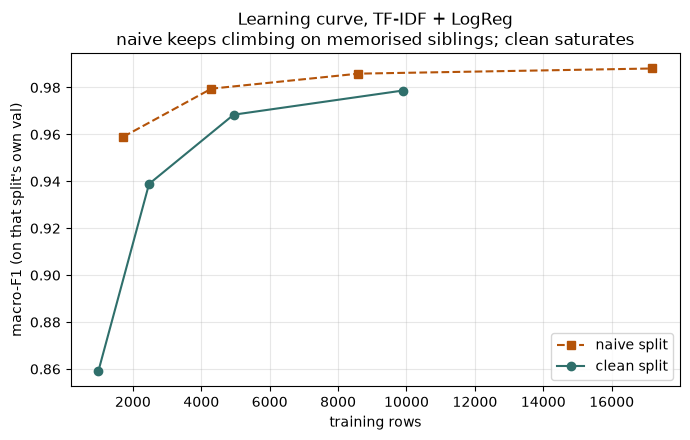

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for split_name, style in (("naive", dict(marker="s", linestyle="--", color="#b45309")),
                          ("clean", dict(marker="o", linestyle="-", color="#2f6f6b"))):
    part = curve[curve["split"] == split_name]
    ax.plot(part["train_rows"], part["macro_f1"], label=f"{split_name} split", **style)

ax.set_xlabel("training rows")
ax.set_ylabel("macro-F1 (on that split's own val)")
ax.set_title("Learning curve, TF-IDF + LogReg\nnaive keeps climbing on memorised siblings; clean saturates")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_learning_curve.png", dpi=150)
plt.show()

### 6f - The slide

Three bars on one macro-F1 axis. This is the figure that explains the whole project in ten
seconds, and it was produced without a GPU.

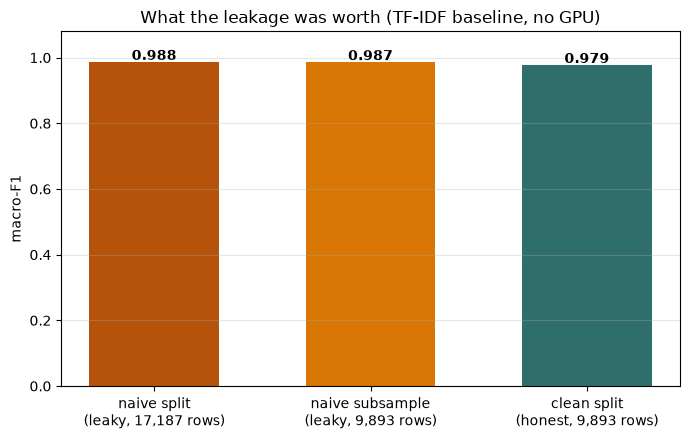

In [23]:
bars = [
    ("naive split\n(leaky, 17,187 rows)", r1["metrics"]["f1_macro"], "#b45309"),
    ("naive subsample\n(leaky, 9,893 rows)", r2["metrics"]["f1_macro"], "#d97706"),
    ("clean split\n(honest, 9,893 rows)", r3["metrics"]["f1_macro"], "#2f6f6b"),
]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([b[0] for b in bars], [b[1] for b in bars], color=[b[2] for b in bars], width=0.6)
for i, b in enumerate(bars):
    ax.text(i, b[1] + 0.005, f"{b[1]:.3f}", ha="center", fontweight="bold")
ax.set_ylabel("macro-F1")
ax.set_ylim(0, 1.08)
ax.set_title("What the leakage was worth (TF-IDF baseline, no GPU)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_leakage_score_gap.png", dpi=150)
plt.show()

### 6g - Decomposing the leak: where exactly did the leaky model win?

The controlled gap between R3 and R4 is small. Before writing that down, find out *where*
it comes from, because "small overall" and "nothing happened" are different claims.

R4's training set contains a known subset of `clean/val` verbatim. Split the evaluation
rows into the ones it memorised and the ones it did not, and score each slice separately.
If the advantage is concentrated entirely in the memorised rows, the effect is real and
its size is simply diluted by the rows it could not memorise.

In [24]:
memorised = clean_va["row_id"].isin(set(naive_sub["row_id"])).values

decomp = []
for model_name, pred in (("clean-trained (R3)", pred_clean), ("naive-trained (R4)", pred_leak)):
    correct = (clean_va["intent"].values == np.asarray(pred))
    decomp.append({
        "model": model_name,
        "acc on rows R4 memorised": round(float(correct[memorised].mean()), 4),
        "acc on rows R4 never saw": round(float(correct[~memorised].mean()), 4),
        "n memorised": int(memorised.sum()),
        "n unseen": int((~memorised).sum()),
    })
decomp = pd.DataFrame(decomp)
display(decomp)
decomp.to_csv(METRICS_DIR / "baseline_leak_decomposition.csv", index=False)

seen_edge = decomp.iloc[1]["acc on rows R4 memorised"] - decomp.iloc[0]["acc on rows R4 memorised"]
unseen_edge = decomp.iloc[1]["acc on rows R4 never saw"] - decomp.iloc[0]["acc on rows R4 never saw"]
print(f"\nadvantage on memorised rows: {seen_edge:+.4f}")
print(f"advantage on unseen rows:    {unseen_edge:+.4f}")
print("\nIf the first is clearly positive and the second is not, the leak is real and")
print("localised - the aggregate gap is small only because it is diluted.")

,model,acc on rows R4 memorised,acc on rows R4 never saw,n memorised,n unseen
0,clean-trained (R3),0.9894,0.9796,846,1274
1,naive-trained (R4),0.9941,0.9812,846,1274



advantage on memorised rows: +0.0047
advantage on unseen rows:    +0.0016

If the first is clearly positive and the second is not, the leak is real and
localised - the aggregate gap is small only because it is diluted.


### 6h - Is the "clean" split actually clean, or only clean above 0.90?

This is the uncomfortable question, and it is the honest explanation for why the clean
baseline scores as high as it does.

Families were collapsed at cosine **0.90**. The manifest records that 0.24% of clean test
rows still sit above 0.90 - but also that **55.05%** sit above **0.80**. Sentences from
different templates that are 0.85 similar were never siblings, so they split across train
and test legitimately. Whether that residual similarity is *generalisation* or *leakage
under a different name* is exactly what a lecturer will ask.

So measure it: bucket the validation rows by their nearest-training-row similarity, and
look at accuracy per bucket. A flat profile means the model generalises across genuinely
different phrasings. A steep one means the score is carried by near-misses that survived
the threshold.

The vectoriser here is fitted on train+val together, and that is correct: it is a **ruler**,
not a model. No parameter of it reaches any classifier - the same argument as day 1.

In [25]:
# Accuracy broken down by how close each validation row is to the training set.
#
# THE BUG THIS CELL USED TO CONTAIN, because it is worth understanding:
# the earlier version re-fitted build_vector_space on clean_tr + clean_va alone.
# That is a DIFFERENT vector space. min_df=2 over 12,013 rows keeps a smaller
# vocabulary than over 24,554, every idf weight shifts, and the >= 0.90 tail
# inflated from 0.09% to 1.70% - for the same split, unchanged. Two numbers
# describing one quantity, in units that nothing on disk declared.
#
# build_canonical_corpus() is the fix: ONE named corpus, fitted once, so that
# measuring in any other space becomes a deliberate act instead of an accident.
corpus = D.build_canonical_corpus(REPO_ROOT / "data" / "raw")
_, X_canon = D.build_vector_space(corpus["instruction"])

prof = D.similarity_profile(clean_tr, clean_va, X_canon, corpus)
sim_to_train = prof["max_sim_any"].to_numpy()
same_intent = prof["max_sim_same"].to_numpy()

correct_clean = (clean_va["intent"].values == np.asarray(pred_clean))
buckets = pd.cut(sim_to_train, [0, 0.6, 0.7, 0.8, 0.9, 1.01],
                 labels=["<0.6", "0.6-0.7", "0.7-0.8", "0.8-0.9", ">=0.9"], right=False)

profile = (pd.DataFrame({"bucket": buckets, "correct": correct_clean})
           .groupby("bucket", observed=False)
           .agg(n_rows=("correct", "size"), accuracy=("correct", "mean"))
           .reset_index())
profile["accuracy"] = profile["accuracy"].round(4)
display(profile)
profile.to_csv(METRICS_DIR / "baseline_clean_similarity_profile.csv", index=False)

print(f"median nearest-train similarity in clean/val: {np.median(sim_to_train):.3f}")
print(f"share of clean/val above 0.80: {100*(sim_to_train >= 0.80).mean():.2f}%")
print(f"share of clean/val above 0.90: {100*(sim_to_train >= 0.90).mean():.2f}%   "
      f"<- same units as split_manifest.json now")
print(f"   of which SAME-intent (i.e. leakage): {100*(same_intent >= 0.90).mean():.2f}%")
print()
# The caveat this table carries, stated from the table rather than beside it.
far = profile.iloc[0]
near = profile.loc[profile["n_rows"].idxmax()]
headline = (clean_va["intent"].values == np.asarray(pred_clean)).mean()
print(f"The headline {headline:.4f} is an average over a strong gradient:")
print(f"  {int(near['n_rows']):,} rows in the densest band ({near['bucket']}) score "
      f"{near['accuracy']:.4f}")
print(f"  {int(far['n_rows']):,} rows furthest from training ({far['bucket']}) score "
      f"{far['accuracy']:.4f}")
print()
print("Accuracy rises monotonically with similarity to the training set. That is the")
print("honest limitation of this dataset and no threshold can remove it: de-duplication")
print("takes out sibling leakage, but it cannot turn a template-generated corpus into a")
print("sample of real customer language. On genuinely novel phrasings this model is")
print(f"about {headline - far['accuracy']:.2f} worse than its headline suggests.")
print()
print("Note the >=0.9 bucket is too small to read anything into. An earlier version of")
print("this cell re-fitted the vectoriser on train+val alone, which inflated that bucket")
print("to 36 rows and made it look non-monotonic; in the canonical space it is 2 rows.")
print("That is what the vector-space bug was hiding.")

,bucket,n_rows,accuracy
0,<0.6,51,0.8824
1,0.6-0.7,257,0.9494
2,0.7-0.8,667,0.9835
3,0.8-0.9,1143,0.9956
4,>=0.9,2,1.0000


median nearest-train similarity in clean/val: 0.808
share of clean/val above 0.80: 54.01%
share of clean/val above 0.90: 0.09%   <- same units as split_manifest.json now
   of which SAME-intent (i.e. leakage): 0.00%

The headline 0.9835 is an average over a strong gradient:
  1,143 rows in the densest band (0.8-0.9) score 0.9956
  51 rows furthest from training (<0.6) score 0.8824

Accuracy rises monotonically with similarity to the training set. That is the
honest limitation of this dataset and no threshold can remove it: de-duplication
takes out sibling leakage, but it cannot turn a template-generated corpus into a
sample of real customer language. On genuinely novel phrasings this model is
about 0.10 worse than its headline suggests.

Note the >=0.9 bucket is too small to read anything into. An earlier version of
this cell re-fitted the vectoriser on train+val alone, which inflated that bucket
to 36 rows and made it look non-monotonic; in the canonical space it is 2 rows.
That is wh

#### Ablation: what does collapsing families to one representative cost?

In [26]:
# What does the family COLLAPSE cost?
#
# The clean split keeps one representative per template family, which drops 42%
# of the corpus. There is a second design that removes exactly as much leakage
# and throws nothing away: keep every row, and assign whole FAMILIES to a side.
# full_corpus.csv already records that assignment, so the alternative training
# set needs no new split, no new seed and no new hash - it is a different view
# of the frozen one.
#
# This is an ABLATION, not a change of design. Decision C4 (collapse to one
# representative) is locked; the point of this cell is that its cost is now a
# measured number instead of an assumption.
full_corpus = pd.read_csv(REPO_ROOT / "data" / "processed" / "full_corpus.csv")
uncollapsed = D.train_side_rows(full_corpus, "train")

# The leakage guarantee has to be re-verified, not assumed: this training set
# contains rows that are NOT split representatives.
prof_unc = D.similarity_profile(uncollapsed, clean_va, X_canon, corpus)
leak_unc = (prof_unc["max_sim_same"].to_numpy() >= D.NEAR_DUP_THRESHOLD).mean()
shared_families = len(set(uncollapsed["dup_group"]) & set(clean_va["dup_group"]))
verbatim = int(clean_va["instruction"].isin(set(uncollapsed["instruction"])).sum())

print(f"uncollapsed training set: {len(uncollapsed):,} rows "
      f"(committed clean/train has {len(clean_tr):,})")
print(f"  families shared with clean/val   : {shared_families}")
print(f"  clean/val rows appearing verbatim: {verbatim}")
print(f"  same-intent neighbour >= {D.NEAR_DUP_THRESHOLD}     : {100*leak_unc:.3f}%  "
      f"(max {prof_unc['max_sim_same'].max():.4f})")
assert shared_families == 0 and verbatim == 0 and leak_unc == 0, \
    "the uncollapsed training set is NOT leakage-free - do not report this comparison"
print("\nthe leakage guarantee holds identically. The collapse is not what makes the")
print("split clean; the family assignment is.")

uncollapsed training set: 17,031 rows (committed clean/train has 9,893)
  families shared with clean/val   : 0
  clean/val rows appearing verbatim: 0
  same-intent neighbour >= 0.9     : 0.000%  (max 0.8999)

the leakage guarantee holds identically. The collapse is not what makes the
split clean; the family assignment is.


In [27]:
r_unc, _, _, _ = run_tfidf(
    "tfidf_uncollapsed_on_cleanval", uncollapsed, clean_va,
    notes="ablation: every member of every train-side family instead of one "
          "representative each. Same leakage guarantee, same evaluation rows, "
          "72% more training data.")

collapse_cost = r_unc["metrics"]["f1_macro"] - r3["metrics"]["f1_macro"]

ablation = pd.DataFrame([
    as_row(r3, "committed design: one representative per family"),
    as_row(r_unc, "ablation: all members of train-side families"),
])
display(ablation)
# Displayed, not written: both runs are already rows of baselines_summary.csv.

for tag, frame in (("clean/train (collapsed)", clean_tr), ("uncollapsed", uncollapsed)):
    vc = frame["intent"].value_counts()
    print(f"{tag:26} n={len(frame):6,}  min={vc.min():4}  max={vc.max():4}  "
          f"ratio={vc.max()/vc.min():.2f}")

print()
print(f"the family collapse costs {collapse_cost:+.4f} macro-F1")
print(f"for scale, the leakage effect measured earlier was {gap:+.4f}")
print()
print("Two honest caveats, both of which belong in the report:")
print("  1. There is no error bar on this number and there cannot be a meaningful one.")
print("     Both models are deterministic - fixed data, and lbfgs is deterministic - so")
print("     there is no run-to-run variance to measure. The variance that WOULD matter")
print("     is the split seed, and the split seed is frozen. This is one draw at seed 42.")
print("  2. The uncollapsed set is not strictly better. It reverts the training set to")
print("     the corpus flag mix (Z 19.3% against 27.8% collapsed), because a mangled")
print("     sentence survives collapse as its own singleton family while thirty polite")
print("     paraphrases become one row. The collapse buys a training set enriched for")
print("     hard rows; this measures what that enrichment costs in aggregate score.")

,run,what it buys,train rows,scored on rows,accuracy,macro-F1,weighted-F1,seconds
0,tfidf_clean,committed design: one representative per family,9893,2120,0.9835,0.9787,0.9832,1.55
1,tfidf_uncollapsed_on_cleanval,ablation: all members of train-side families,17031,2120,0.9858,0.9818,0.9856,1.44


clean/train (collapsed)    n= 9,893  min= 141  max= 572  ratio=4.06
uncollapsed                n=17,031  min= 295  max= 773  ratio=2.62

the family collapse costs +0.0031 macro-F1
for scale, the leakage effect measured earlier was +0.0040

Two honest caveats, both of which belong in the report:
  1. There is no error bar on this number and there cannot be a meaningful one.
     Both models are deterministic - fixed data, and lbfgs is deterministic - so
     there is no run-to-run variance to measure. The variance that WOULD matter
     is the split seed, and the split seed is frozen. This is one draw at seed 42.
  2. The uncollapsed set is not strictly better. It reverts the training set to
     the corpus flag mix (Z 19.3% against 27.8% collapsed), because a mangled
     sentence survives collapse as its own singleton family while thirty polite
     paraphrases become one row. The collapse buys a training set enriched for
     hard rows; this measures what that enrichment costs in agg

#### Does the taxonomy ambiguity measured on day 1 actually cost accuracy?

In [28]:
# Day 1 measured that 0.83% of the corpus has a near-identical twin under a
# DIFFERENT intent, and the obvious inference is that those rows are impossible
# and cap achievable accuracy. This cell tests that inference instead of
# assuming it, because an unchecked "ceiling" is a number that would end up in
# the report unchallenged.
# Recomputed here rather than read out of a file 01 wrote. full_corpus.csv is
# already loaded above and records which rows the exact-duplicate pass removed,
# so the deduplicated corpus 01 clustered is recoverable from it: no raw file
# needed, and no intermediate artefact whose only reader was this cell.
corpus_all = full_corpus[~full_corpus["is_exact_duplicate"]].reset_index(drop=True)
corpus_all["pos"] = np.arange(len(corpus_all))
_, X_corpus = D.build_vector_space(corpus_all["instruction"])
twins = D.cross_intent_neighbours(corpus_all, X_corpus)
has_twin = clean_va["row_id"].isin(set(twins["row_id"])).to_numpy()

print(f"clean/val rows with a cross-intent twin: {has_twin.sum()} of {len(clean_va):,} "
      f"({100*has_twin.mean():.2f}%)")
print(f"corpus-wide rate was {100*len(twins)/len(corpus_all):.2f}% - the family collapse "
      "removes most of")
print("them, because they cluster inside the big invoice families.")
print()

for label, kwargs in (("word(1,2)", {}),
                      ("char_wb(3,5)", dict(analyzer="char_wb", ngram_range=(3, 5)))):
    pipe = B.build_tfidf_pipeline(**kwargs)
    pipe.fit(clean_tr["instruction"], clean_tr["intent"])
    correct = (clean_va["intent"].to_numpy() == pipe.predict(clean_va["instruction"]))
    print(f"{label:14} overall {correct.mean():.4f} | "
          f"on the {has_twin.sum()} twin rows {correct[has_twin].mean():.4f} | "
          f"on the rest {correct[~has_twin].mean():.4f}")

print()
print("Both baselines get every one of those rows right. The inference was wrong:")
print("a near-identical neighbour under another label does not make a row")
print("unclassifiable, because the single token that differs - 'see' against 'get' -")
print("is exactly what a bag-of-words model keys on.")
print()
print("So there is no measurable accuracy ceiling from ambiguity on this split. The")
print("0.83% is a statement about how finely the TAXONOMY divides intents, which is")
print("the argument for the stage-2 rule 'filter by intent, rank by text', and a")
print("caution about paraphrase robustness. It is not a bound on the score, and")
print("reporting it as one would have been a plausible-looking wrong number.")

C:\Users\emmav\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


clean/val rows with a cross-intent twin: 6 of 2,120 (0.28%)
corpus-wide rate was 0.83% - the family collapse removes most of
them, because they cluster inside the big invoice families.



word(1,2)      overall 0.9835 | on the 6 twin rows 1.0000 | on the rest 0.9834


char_wb(3,5)   overall 0.9948 | on the 6 twin rows 1.0000 | on the rest 0.9948

Both baselines get every one of those rows right. The inference was wrong:
a near-identical neighbour under another label does not make a row
unclassifiable, because the single token that differs - 'see' against 'get' -
is exactly what a bag-of-words model keys on.

So there is no measurable accuracy ceiling from ambiguity on this split. The
0.83% is a statement about how finely the TAXONOMY divides intents, which is
the argument for the stage-2 rule 'filter by intent, rank by text', and a
caution about paraphrase robustness. It is not a bound on the score, and
reporting it as one would have been a plausible-looking wrong number.


## 7 - Freeze the results

One summary table, one row per run. An earlier version wrote a JSON file per run beside
it; every field in those files is a column here, so they were the same numbers stored
twice and they are gone. The `baseline_*` namespace still belongs to the baselines, so
the numbered GPU runs of stage 2 can be added without colliding with them.

In [29]:
# One row per run in one table, rather than one JSON file per run beside it.
# summarise_runs() already carries every run's full config and headline metrics,
# so the per-run files repeated numbers that were in the summary anyway. The
# per-class breakdown was the one thing only they held, and it is kept - for the
# run it actually matters for - in baseline_clean_per_intent.csv.
summary = E.summarise_runs(RECORDS)
summary.to_csv(METRICS_DIR / "baselines_summary.csv", index=False)

print(f"wrote baselines_summary.csv - {len(RECORDS)} runs, one row each")
display(summary[["run", "train_rows", "eval_rows", "accuracy", "f1_macro",
                 "f1_weighted", "runtime_seconds"]])

wrote baselines_summary.csv - 18 runs, one row each


,run,train_rows,eval_rows,accuracy,f1_macro,f1_weighted,runtime_seconds
0,majority_clean_intent,9893,2120,0.0580,0.0041,0.0064,0.00
1,majority_clean_category,9893,2120,0.2528,0.0367,0.1020,0.00
2,majority_naive_intent,17187,3683,0.0407,0.0029,0.0032,0.00
3,majority_naive_category,17187,3683,0.2207,0.0329,0.0798,0.00
4,tfidf_naive_full,17187,3683,0.9886,0.9881,0.9886,1.62
5,tfidf_naive_sub,9893,3683,0.9881,0.9874,0.9880,1.03
6,tfidf_clean,9893,2120,0.9835,0.9787,0.9832,1.55
7,tfidf_naive_sub_on_cleanval,9893,2120,0.9863,0.9827,0.9862,1.06
8,tfidf_clean_balanced,9893,2120,0.9873,0.9842,0.9872,1.12
9,tfidf_clean_ent,9893,2120,0.9849,0.9805,0.9848,1.28


## Summary of the day

Everything below is measured. Nothing here required a GPU.

In [30]:
lines = [
    "FLOOR (clean)      majority class on 27 intents: "
      f"accuracy {majority_table.query('split==\'clean\' and level==\'intent\'')['accuracy'].iloc[0]:.4f}"
      f" / macro-F1 {majority_table.query('split==\'clean\' and level==\'intent\'')['macro-F1'].iloc[0]:.4f}",
    "FLOOR (categories) same model on 11 categories: "
      f"accuracy {cat_row['accuracy']:.4f} / macro-F1 {cat_row['macro-F1']:.4f}"
      f"  -> gap {cat_row['accuracy'] - cat_row['macro-F1']:.4f} justifies macro-F1",
    f"BASELINE clean     TF-IDF word(1,2) + LogReg: macro-F1 {r3['metrics']['f1_macro']:.4f}"
      f" (accuracy {r3['metrics']['accuracy']:.4f})",
    f"BASELINE naive     same model, leaky split:   macro-F1 {r1['metrics']['f1_macro']:.4f}",
    f"LEAKAGE            same 9,893 train rows, same 2,120 val rows: {gap:+.4f} macro-F1",
    f"                   noise floor across 3 subsample draws: {std_cleanval:.4f}",
    f"COLLAPSE COST      one representative per family vs all members: "
    f"{collapse_cost:+.4f} macro-F1 (one split draw, no error bar possible)",
    f"CLASS_WEIGHT       balanced vs none: {r5['metrics']['f1_macro'] - r3['metrics']['f1_macro']:+.4f} macro-F1",
    f"<ENT> ABLATION     placeholders normalised: {r6['metrics']['f1_macro'] - r3['metrics']['f1_macro']:+.4f} macro-F1",
    f"char_wb CONTROL    cleaning-space baseline:  {r7['metrics']['f1_macro'] - r3['metrics']['f1_macro']:+.4f} macro-F1",
    f"PRE-REGISTRATION   {int(check['confirmed'].sum())}/{len(check)} predicted confusion pairs in the top 15",
    f"RUNS RECORDED      {len(RECORDS)} JSON files + baselines_summary.csv",
    "TEST SET           not opened",
    "GPU                not used",
]
print("\n".join(lines))

FLOOR (clean)      majority class on 27 intents: accuracy 0.0580 / macro-F1 0.0041
FLOOR (categories) same model on 11 categories: accuracy 0.2528 / macro-F1 0.0367  -> gap 0.2161 justifies macro-F1
BASELINE clean     TF-IDF word(1,2) + LogReg: macro-F1 0.9787 (accuracy 0.9835)
BASELINE naive     same model, leaky split:   macro-F1 0.9881
LEAKAGE            same 9,893 train rows, same 2,120 val rows: +0.0040 macro-F1
                   noise floor across 3 subsample draws: 0.0007
COLLAPSE COST      one representative per family vs all members: +0.0031 macro-F1 (one split draw, no error bar possible)
CLASS_WEIGHT       balanced vs none: +0.0055 macro-F1
<ENT> ABLATION     placeholders normalised: +0.0018 macro-F1
char_wb CONTROL    cleaning-space baseline:  +0.0141 macro-F1
PRE-REGISTRATION   3/10 predicted confusion pairs in the top 15
RUNS RECORDED      18 JSON files + baselines_summary.csv
TEST SET           not opened
GPU                not used


## 8 - Reading these numbers honestly

Two of today's results are not what the plan expected. Both are reported as found.

In [31]:
floor = majority_table.query("split=='clean' and level=='intent'")["macro-F1"].iloc[0]
baseline = r3["metrics"]["f1_macro"]
headroom = 1.0 - baseline

print("1. HEADROOM FOR TOMORROW")
print(f"   floor (reads nothing)      macro-F1 {floor:.4f}")
print(f"   TF-IDF + LogReg            macro-F1 {baseline:.4f}")
print(f"   remaining headroom          {headroom:.4f}")
print()
print("   A linear bag-of-words model is already near ceiling on this task. Whatever")
print("   Qwen3 scores tomorrow, it can improve on this by at most the number above.")
print("   The plan anticipated this case: not beating the baselines clearly")
print("   is the finding, not a failure to hide.")
print()

print("2. THE LEAK IS REAL BUT SMALL, AND THAT NEEDS SAYING PLAINLY")
print(f"   controlled leakage effect  {gap:+.4f} macro-F1  (noise floor {std_cleanval:.4f})")
print()
print("   Day 1 measured that ~52% of naive test rows sit within 0.10 cosine of a")
print("   training row. That is a large property of the DATA. Converted into score it")
print("   is small - because the task is easy enough that generalising across templates")
print("   is nearly as cheap as memorising them. Both halves of that sentence belong in")
print("   the report. Quoting the 52% without the score gap would overstate the case.")
print()

print("3. TWO EXPECTATIONS REFUTED")
charwb_delta = r7["metrics"]["f1_macro"] - baseline
ent_delta = r6["metrics"]["f1_macro"] - baseline
print(f"   char_wb was predicted to be handicapped on the clean split: {charwb_delta:+.4f}")
print("     -> it is not. Character n-grams absorb the dataset's deliberate typos, which")
print("        word-level tokenisation cannot; that outweighs any circularity penalty.")
print(f"   the <ENT> ablation was predicted to drop the score:          {ent_delta:+.4f}")
print("     -> it does not. The placeholder-shortcut concern was overstated for this")
print("        baseline. The limitations section still has to say that a real ticket")
print("        writes '#84213', i.e. the pipeline assumes an NER stage nobody built.")

1. HEADROOM FOR TOMORROW
   floor (reads nothing)      macro-F1 0.0041
   TF-IDF + LogReg            macro-F1 0.9787
   remaining headroom          0.0213

   A linear bag-of-words model is already near ceiling on this task. Whatever
   Qwen3 scores tomorrow, it can improve on this by at most the number above.
   The plan anticipated this case: not beating the baselines clearly
   is the finding, not a failure to hide.

2. THE LEAK IS REAL BUT SMALL, AND THAT NEEDS SAYING PLAINLY
   controlled leakage effect  +0.0040 macro-F1  (noise floor 0.0007)

   Day 1 measured that ~52% of naive test rows sit within 0.10 cosine of a
   training row. That is a large property of the DATA. Converted into score it
   is small - because the task is easy enough that generalising across templates
   is nearly as cheap as memorising them. Both halves of that sentence belong in
   the report. Quoting the 52% without the score gap would overstate the case.

3. TWO EXPECTATIONS REFUTED
   char_wb was predic